# Movie Popularity Level Classification

Classify movies into `{Very Low, Low, Medium, High}` popularity levels.

**Milestone 2** — builds directly on the preprocessing pipeline from Milestone 1.

Pipeline: Load & Clean → Feature Engineering → Encoding → Imputation → Feature Selection → Classification Models → Hyperparameter Tuning → Comparison → Save Models

## 1. Import & Load Data

In [2]:
import subprocess
import sys
subprocess.run([sys.executable, "-m", "pip", "install", "xgboost"], check=True)

CompletedProcess(args=['C:\\Users\\uosef mohamed\\AppData\\Local\\Programs\\Python\\Python313\\python.exe', '-m', 'pip', 'install', 'xgboost'], returncode=0)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# ── Load the updated dataset (has popularityLevel instead of popularity) ──
df = pd.read_csv("train_data.csv", low_memory=False).copy()
print("Loaded:", df.shape)
print("\nTarget (popularityLevel) value counts:")
print(df["popularityLevel"].value_counts())
print("\nClass distribution %:")
print(df["popularityLevel"].value_counts(normalize=True).round(3) * 100)

Loaded: (1048575, 39)

Target (popularityLevel) value counts:
popularityLevel
Very Low    808170
Low         146963
Medium       77945
High         15497
Name: count, dtype: int64

Class distribution %:
popularityLevel
Very Low    77.1
Low         14.0
Medium       7.4
High         1.5
Name: proportion, dtype: float64


## 2. Pre-Split Cleaning

Same cleaning as Milestone 1 — identical logic, just the target column changes.

In [4]:
# ── Remove duplicates ──
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

# ── Fix data types ──
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["theatrical"] = df["theatrical"].astype(int)
df["adult"] = (
    df["adult"].map({"False": 0, "True": 1, False: 0, True: 1}).fillna(0).astype(int)
)

# ── Clip impossible values ──
df["revenue"] = df["revenue"].clip(lower=0)
df["budget"]  = df["budget"].clip(lower=0)
df["runtime"] = df["runtime"].clip(lower=0).replace(0, np.nan)

# ── Invalid release dates ──
df["release_date"] = df["release_date"].where(
    df["release_date"].between("1888-01-01", "2026-12-31"), other=pd.NaT
)

# ── Encode movie_sentiment ──
sentiment_map = {"positive": 1, "neutral": 0, "negative": -1}
if "movie_sentiment" in df.columns:
    df["sentiment_encoded"] = df["movie_sentiment"].map(sentiment_map).fillna(0)

# ── Fill text / list columns ──
text_cols = ["title", "original_title", "overview", "tagline",
             "backdrop_path", "homepage", "imdb_id", "poster_path"]
for c in text_cols:
    df[c] = df[c].fillna("Unknown" if c in ("title", "original_title") else "")

for c in ["genres", "production_companies", "production_countries", "spoken_languages"]:
    df[c] = df[c].fillna("")

print("Pre-split cleaning done. Shape:", df.shape)

Duplicates removed: 166
Pre-split cleaning done. Shape: (1048409, 39)


## 3. Encode Target & Train/Test Split

In [5]:
# ── Ordinal encoding for the 4 classes ──
# Very Low=0, Low=1, Medium=2, High=3  (natural order)
level_map = {"Very Low": 0, "Low": 1, "Medium": 2, "High": 3}
df["target"] = df["popularityLevel"].map(level_map)

# Drop any rows where target is NaN (unknown label)
df = df.dropna(subset=["target"])
df["target"] = df["target"].astype(int)

print("Class distribution after encoding:")
print(df["target"].value_counts().sort_index())

TARGET = "target"
X = df.drop(columns=[TARGET, "popularityLevel"])  # drop both label columns
y = df[TARGET]

# 80 / 20 split — stratified to keep class ratios equal in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)
print(f"\nX_train: {X_train.shape}  |  X_test: {X_test.shape}")
print("Train class dist:\n", y_train.value_counts().sort_index())
print("Test  class dist:\n", y_test.value_counts().sort_index())

Class distribution after encoding:
target
0    808031
1    146941
2     77940
3     15497
Name: count, dtype: int64

X_train: (838727, 38)  |  X_test: (209682, 38)
Train class dist:
 target
0    646425
1    117553
2     62352
3     12397
Name: count, dtype: int64
Test  class dist:
 target
0    161606
1     29388
2     15588
3      3100
Name: count, dtype: int64


## 4. Feature Engineering

Identical to Milestone 1 — applied separately to train and test to avoid leakage.

In [6]:
for df_fe in [X_train, X_test]:

    # Date features
    df_fe["release_year"]    = df_fe["release_date"].dt.year
    df_fe["release_month"]   = df_fe["release_date"].dt.month
    df_fe["release_quarter"] = df_fe["release_date"].dt.quarter
    df_fe["is_summer"]       = df_fe["release_month"].isin([6, 7, 8]).astype(int)
    df_fe["is_holiday"]      = df_fe["release_month"].isin([11, 12]).astype(int)
    df_fe["movie_age"]       = (2025 - df_fe["release_year"]).clip(lower=0)
    df_fe["is_recent"]       = (df_fe["release_year"] >= 2015).astype(int)

    # Metadata presence flags
    df_fe["has_overview"]  = (df_fe["overview"].str.strip()  != "").astype(int)
    df_fe["has_tagline"]   = (df_fe["tagline"].str.strip()   != "").astype(int)
    df_fe["has_homepage"]  = (df_fe["homepage"].str.strip()  != "").astype(int)
    df_fe["has_poster"]    = (df_fe["poster_path"].str.strip()    != "").astype(int)
    df_fe["has_backdrop"]  = (df_fe["backdrop_path"].str.strip()  != "").astype(int)
    df_fe["has_imdb"]      = (df_fe["imdb_id"].str.strip()        != "").astype(int)
    df_fe["has_budget"]    = (df_fe["budget"] > 0).astype(int)
    df_fe["has_revenue"]   = (df_fe["revenue"] > 0).astype(int)

    # Log-transforms (compress right-skewed distributions)
    df_fe["log_vote_count"] = np.log1p(df_fe["vote_count"])
    df_fe["log_budget"]     = np.log1p(df_fe["budget"])
    df_fe["log_revenue"]    = np.log1p(df_fe["revenue"])

    df_fe["profit"]     = (df_fe["revenue"] - df_fe["budget"]).clip(lower=0)
    df_fe["log_profit"] = np.log1p(df_fe["profit"])
    df_fe["has_profit"] = (df_fe["profit"] > 0).astype(int)

    # Genre / company / country features
    df_fe["genre_count"]   = df_fe["genres"].apply(
        lambda x: len([g for g in str(x).split(",") if g.strip()]) if x else 0)
    df_fe["company_count"] = df_fe["production_companies"].apply(
        lambda x: len([c for c in str(x).split(",") if c.strip()]) if x else 0)
    df_fe["country_count"] = df_fe["production_countries"].apply(
        lambda x: len([c for c in str(x).split(",") if c.strip()]) if x else 0)

    df_fe["is_us_production"] = (
        df_fe["production_countries"].str.contains("United States of America", na=False).astype(int))
    df_fe["is_uk_production"] = (
        df_fe["production_countries"].str.contains("United Kingdom", na=False).astype(int))
    df_fe["is_international"] = (df_fe["country_count"] > 1).astype(int)

    df_fe["spoken_lang_count"] = df_fe["spoken_languages"].apply(
        lambda x: len([l for l in str(x).split(",") if l.strip()]) if x else 0)
    df_fe["is_english_lang"]  = (
        df_fe["spoken_languages"].str.contains("English", na=False).astype(int))
    df_fe["is_multilingual"] = (df_fe["spoken_lang_count"] > 1).astype(int)

    df_fe["overview_len"] = df_fe["overview"].str.split().str.len().fillna(0)

print("Feature engineering done.")
print("X_train shape:", X_train.shape)

Feature engineering done.
X_train shape: (838727, 69)


## 5. Encoding Categorical Columns

In [7]:
# ── Quality & Status ordinal encoding ──
quality_map = {"real_confident": 5, "real_likely": 4, "stub_legitimate": 3,
               "stub_uncertain": 2, "spam_likely": 1, "spam_confident": 0}
X_train["quality_encoded"] = X_train["quality"].map(quality_map)
X_test["quality_encoded"]  = X_test["quality"].map(quality_map)

status_map = {"Released": 5, "Post Production": 4, "In Production": 3,
              "Planned": 2, "Rumored": 1, "Canceled": 0}
X_train["status_encoded"] = X_train["status"].map(status_map)
X_test["status_encoded"]  = X_test["status"].map(status_map)
fill_status = X_train["status_encoded"].median()
X_train["status_encoded"] = X_train["status_encoded"].fillna(fill_status)
X_test["status_encoded"]  = X_test["status_encoded"].fillna(fill_status)

# ── Original language (fit on train only → no leakage) ──
top_langs = X_train["original_language"].value_counts().nlargest(15).index.tolist()
X_train["lang_group"] = X_train["original_language"].apply(lambda x: x if x in top_langs else "other")
X_test["lang_group"]  = X_test["original_language"].apply(lambda x: x if x in top_langs else "other")
lang_tr = pd.get_dummies(X_train["lang_group"], prefix="lang", dtype=int)
lang_te = pd.get_dummies(X_test["lang_group"],  prefix="lang", dtype=int)
lang_te = lang_te.reindex(columns=lang_tr.columns, fill_value=0)
X_train = pd.concat([X_train, lang_tr], axis=1)
X_test  = pd.concat([X_test,  lang_te], axis=1)

# ── Genre one-hot (fit on train only) ──
all_genres = set()
for val in X_train["genres"].dropna():
    for g in str(val).split(","):
        g = g.strip()
        if g:
            all_genres.add(g)
print(f"Unique genres: {len(all_genres)}")

for genre in sorted(all_genres):
    col = "genre_" + genre.lower().replace(" ", "_").replace("-", "_").replace("&", "and")
    X_train[col] = X_train["genres"].str.contains(genre, na=False).astype(int)
    X_test[col]  = X_test["genres"].str.contains(genre, na=False).astype(int)

# ── Top production companies (fit on train only) ──
company_counts = Counter()
for val in X_train["production_companies"].dropna():
    for c in str(val).split(","):
        c = c.strip()
        if c:
            company_counts[c] += 1
top_companies = [c for c, _ in company_counts.most_common(20)]

for company in top_companies:
    col = "co_" + company.lower().replace(" ", "_").replace("-", "_").replace(".", "")[:25]
    X_train[col] = X_train["production_companies"].str.contains(company, na=False, regex=False).astype(int)
    X_test[col]  = X_test["production_companies"].str.contains(company, na=False, regex=False).astype(int)

print("Encoding done. X_train shape:", X_train.shape)

Unique genres: 19
Encoding done. X_train shape: (838727, 127)


## 6. Imputation & Outlier Capping

In [8]:
# ── Emotion/sentiment columns: missing = no TMDB keywords = fill 0 ──
emotion_cols = [
    "movie_intensity_anger", "movie_intensity_anticipation",
    "movie_intensity_disgust", "movie_intensity_fear",
    "movie_intensity_joy", "movie_intensity_sadness",
    "movie_intensity_surprise", "movie_intensity_trust",
    "movie_valence", "movie_vad_valence", "movie_vad_arousal",
    "movie_vad_dominance", "movie_scl_shift", "movie_scl_coverage",
]
X_train["has_emotion_data"] = X_train["movie_valence"].notna().astype(int)
X_test["has_emotion_data"]  = X_test["movie_valence"].notna().astype(int)

for col in emotion_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna(0)
        X_test[col]  = X_test[col].fillna(0)

# ── Median imputation for numeric columns (fit on train only) ──
other_impute = ["runtime", "release_year", "release_month",
                "release_quarter", "movie_age", "overview_len"]
other_impute = [c for c in other_impute if c in X_train.columns and X_train[c].isnull().any()]
medians = X_train[other_impute].median()
X_train[other_impute] = X_train[other_impute].fillna(medians)
X_test[other_impute]  = X_test[other_impute].fillna(medians)

# ── 3×IQR capping (fit on train only) ──
cap_params = {}   # save for test script
for col in ["runtime", "vote_average", "overview_len"]:
    if col not in X_train.columns:
        continue
    Q1, Q3 = X_train[col].quantile(0.25), X_train[col].quantile(0.75)
    lo, hi = Q1 - 3*(Q3 - Q1), Q3 + 3*(Q3 - Q1)
    cap_params[col] = (lo, hi)
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col]  = X_test[col].clip(lo, hi)
    print(f"Capped {col}: [{lo:.1f}, {hi:.1f}]")

print("\nImputation done.")
print("Nulls in X_train:", int(X_train.isnull().sum().sum()))
print("Nulls in X_test :", int(X_test.isnull().sum().sum()))

Capped runtime: [-168.0, 273.0]
Capped vote_average: [-14.5, 19.3]
Capped overview_len: [-127.0, 188.0]

Imputation done.
Nulls in X_train: 120006
Nulls in X_test : 29946


## 7. Drop Redundant Columns

In [9]:
cols_to_drop = [
    "quality", "status", "original_language", "lang_group",
    "budget", "revenue", "vote_count", "profit",
    "release_date", "genres", "production_companies",
    "production_countries", "spoken_languages",
    "title", "original_title", "overview", "tagline",
    "backdrop_path", "homepage", "imdb_id", "poster_path",
    "adult", "movie_sentiment", "id",
]
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]
X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

print("Dropped:", len(cols_to_drop), "columns")
print("Final X_train shape:", X_train.shape)
print("Final X_test  shape:", X_test.shape)

Dropped: 23 columns
Final X_train shape: (838727, 105)
Final X_test  shape: (209682, 105)


## 8. Feature Selection

For classification we use VarianceThreshold (same as M1) but we re-assess
correlation with the **ordinal target** rather than raw popularity.

In [10]:
# ── Drop near-zero-variance columns ──
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)
keep_mask = selector.get_support()
dropped_low_var = X_train.columns[~keep_mask].tolist()
print(f"Low-variance columns dropped ({len(dropped_low_var)}): {dropped_low_var}")

X_train_v = X_train.loc[:, keep_mask].copy()
X_test_v  = X_test.loc[:, keep_mask].copy()

# ── Correlation with ordinal target (point-biserial / Pearson approx) ──
corr = (
    X_train_v.assign(target=y_train.values)
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("\nTop 20 features by |correlation| with popularityLevel:")
print(corr.head(20).round(4).to_string())

# ── Tree models get all features; Logistic Regression uses curated subset ──
X_train_tree = X_train_v.copy()
X_test_tree  = X_test_v.copy()

linear_core = [
    "log_vote_count", "log_budget", "log_revenue", "log_profit",
    "vote_average", "quality_encoded", "status_encoded", "runtime",
    "has_budget", "has_revenue", "has_imdb", "has_backdrop", "has_poster",
    "has_homepage", "is_us_production", "is_english_lang", "is_multilingual",
    "is_recent", "is_summer", "is_holiday", "movie_age", "genre_count",
    "theatrical", "has_emotion_data", "movie_valence", "sentiment_encoded",
]
linear_core = [c for c in linear_core if c in X_train_v.columns]
X_train_linear = X_train_v[linear_core].copy()
X_test_linear  = X_test_v[linear_core].copy()

print(f"\nTree  features : {X_train_tree.shape[1]}")
print(f"Linear features: {X_train_linear.shape[1]}")

Low-variance columns dropped (32): ['movie_intensity_anger', 'movie_intensity_anticipation', 'movie_intensity_disgust', 'movie_intensity_sadness', 'movie_intensity_surprise', 'movie_scl_shift', 'lang_ar', 'lang_cs', 'lang_nl', 'lang_sv', 'lang_tr', 'genre_western', 'co_warner_bros_pictures', 'co_bbc', 'co_columbia_pictures', 'co_metro_goldwyn_mayer', 'co_arte', 'co_onf_|_nfb', 'co_universal_pictures', 'co_paramount', 'co_zdf', 'co_toei_company', 'co_nikkatsu_corporation', 'co_20th_century_fox', 'co_ard', 'co_canal+', 'co_mosfilm', 'co_toho', 'co_shochiku', 'co_česká_televize', 'co_france_télévisions', 'co_rko_radio_pictures']

Top 20 features by |correlation| with popularityLevel:
log_vote_count        0.7449
quality_encoded       0.5125
vote_average          0.4435
has_backdrop          0.4397
company_count         0.4137
genre_count           0.3934
log_revenue           0.3524
runtime               0.3521
has_emotion_data      0.3289
has_imdb              0.3127
log_profit          

## 9. Evaluation Helper

In [11]:
class_names = ["Very Low", "Low", "Medium", "High"]
results = []   # {Model, Accuracy, Train_time, Test_time}

def evaluate_clf(name, model, X_tr, X_te, y_tr, y_te):
    """Train, time, evaluate and store results for a classifier."""
    # ── Train ──
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    # ── Predict ──
    t0 = time.time()
    y_pred = model.predict(X_te)
    test_time = time.time() - t0

    acc = accuracy_score(y_te, y_pred)

    results.append({
        "Model":      name,
        "Accuracy":   round(acc * 100, 2),
        "Train_time": round(train_time, 3),
        "Test_time":  round(test_time, 4),
    })

    bar = "=" * 60
    print(bar)
    print(f"  {name}")
    print(bar)
    print(f"  Accuracy     : {acc*100:.2f}%")
    print(f"  Training time: {train_time:.3f}s   |  Test time: {test_time:.4f}s")
    print()
    print(classification_report(y_te, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(class_names, rotation=25, ha="right")
    ax.set_yticklabels(class_names)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {name}")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    return model

## 10. Model 1: Logistic Regression

  Logistic Regression
  Accuracy     : 83.47%
  Training time: 14.824s   |  Test time: 0.0819s

              precision    recall  f1-score   support

    Very Low       0.87      0.98      0.92    161606
         Low       0.48      0.17      0.25     29388
      Medium       0.69      0.65      0.67     15588
        High       0.84      0.63      0.72      3100

    accuracy                           0.83    209682
   macro avg       0.72      0.61      0.64    209682
weighted avg       0.80      0.83      0.80    209682



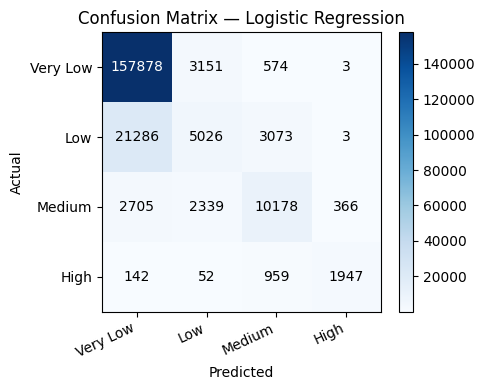

In [12]:
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        C=1.0,
        random_state=42,
    )),
])

best_lr = evaluate_clf("Logistic Regression", pipeline_lr,
                       X_train_linear, X_test_linear, y_train, y_test)

## 11. Model 2: Random Forest Classifier

  Random Forest
  Accuracy     : 78.25%
  Training time: 252.872s   |  Test time: 4.3085s

              precision    recall  f1-score   support

    Very Low       0.95      0.82      0.88    161606
         Low       0.36      0.59      0.45     29388
      Medium       0.64      0.73      0.68     15588
        High       0.69      0.84      0.76      3100

    accuracy                           0.78    209682
   macro avg       0.66      0.74      0.69    209682
weighted avg       0.84      0.78      0.80    209682



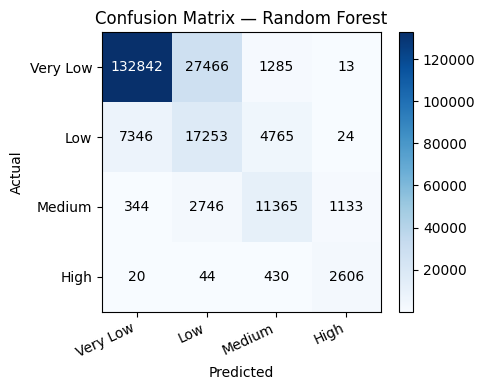

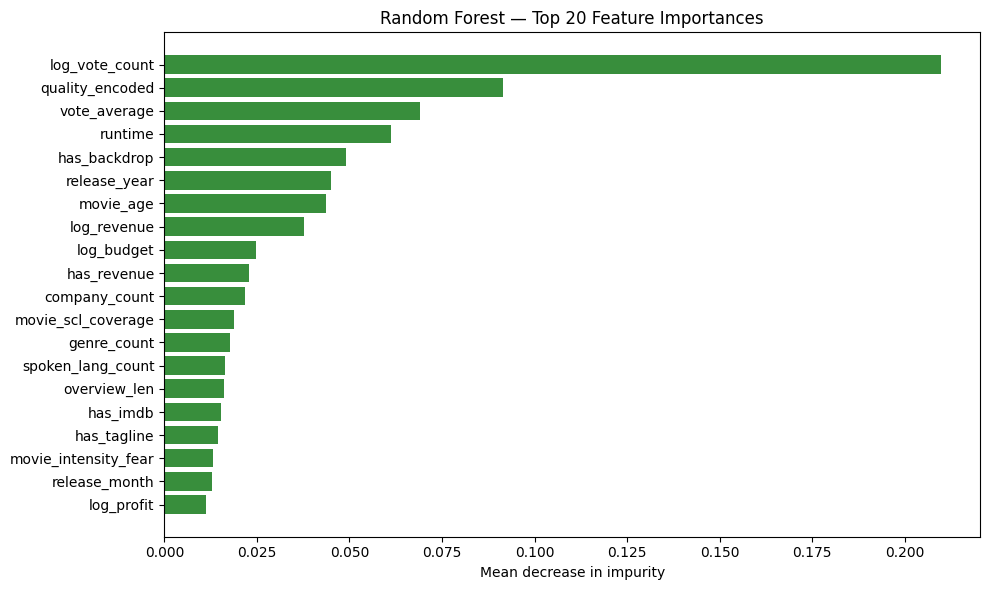

In [13]:
model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

best_rf = evaluate_clf("Random Forest", model_rf,
                       X_train_tree, X_test_tree, y_train, y_test)

# Feature importance plot
imp = pd.Series(model_rf.feature_importances_, index=X_train_tree.columns)
imp = imp.sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
plt.barh(imp.index[::-1], imp.values[::-1], color="#388E3C")
plt.title("Random Forest — Top 20 Feature Importances")
plt.xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

## 12. Model 3: XGBoost Classifier

  XGBoost
  Accuracy     : 85.39%
  Training time: 208.436s   |  Test time: 2.3728s

              precision    recall  f1-score   support

    Very Low       0.89      0.97      0.93    161606
         Low       0.55      0.32      0.41     29388
      Medium       0.76      0.69      0.72     15588
        High       0.84      0.74      0.79      3100

    accuracy                           0.85    209682
   macro avg       0.76      0.68      0.71    209682
weighted avg       0.83      0.85      0.84    209682



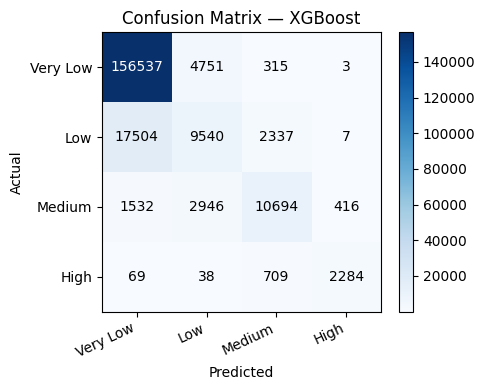

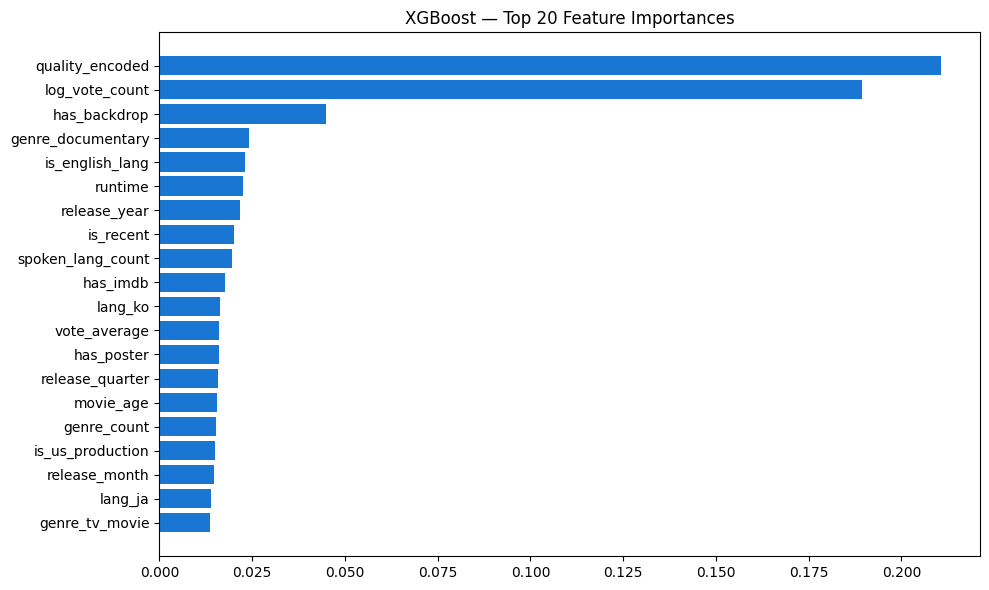

In [14]:
model_xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="multi:softmax",
    num_class=4,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

best_xgb = evaluate_clf("XGBoost", model_xgb,
                        X_train_tree, X_test_tree, y_train, y_test)

imp_xgb = pd.Series(model_xgb.feature_importances_, index=X_train_tree.columns)
imp_xgb = imp_xgb.sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
plt.barh(imp_xgb.index[::-1], imp_xgb.values[::-1], color="#1976D2")
plt.title("XGBoost — Top 20 Feature Importances")
plt.tight_layout()
plt.show()

### Tuning Sample

All hyperparameter tuning is performed on a **25% random stratified sample** of the training set.
This speeds up the search significantly while still producing representative results.
Final models are then trained on the **full** training set.


In [15]:
# ── 25% random sample for hyperparameter tuning (faster, avoids overfitting to full train) ──
X_tune_sample, _, y_tune_sample, _ = train_test_split(
    X_train_tree, y_train,
    train_size=0.25,
    random_state=42,
    stratify=y_train,
)
# Linear models use linear_core features
X_tune_linear_sample = X_tune_sample[[c for c in linear_core if c in X_tune_sample.columns]]

print(f"Full train size : {len(X_train_tree):,}")
print(f"Tuning sample   : {len(X_tune_sample):,}  (25%)")


Full train size : 838,727
Tuning sample   : 209,681  (25%)


## 12b. Model 4: Decision Tree Classifier


  Decision Tree
  Accuracy     : 73.04%
  Training time: 34.675s   |  Test time: 0.1420s

              precision    recall  f1-score   support

    Very Low       0.95      0.76      0.84    161606
         Low       0.31      0.58      0.41     29388
      Medium       0.53      0.67      0.59     15588
        High       0.49      0.82      0.62      3100

    accuracy                           0.73    209682
   macro avg       0.57      0.71      0.61    209682
weighted avg       0.82      0.73      0.76    209682



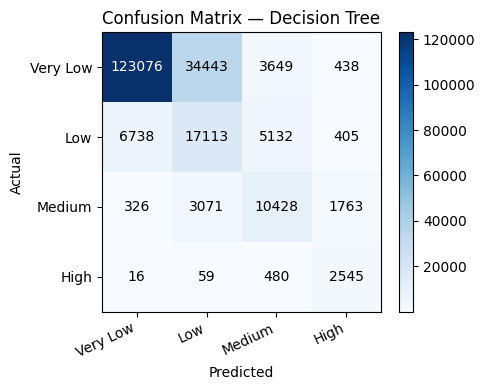

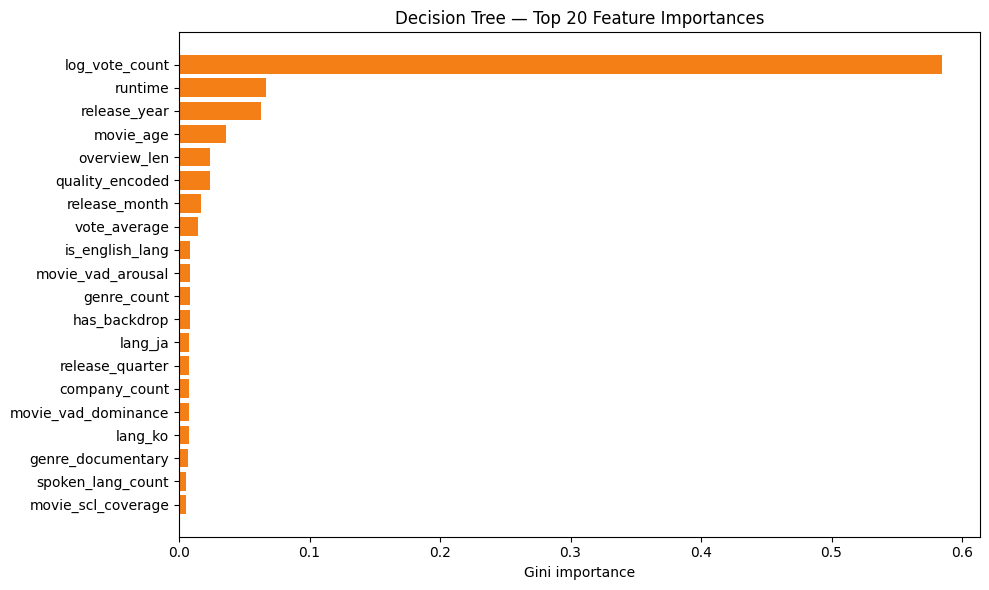

In [16]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    max_depth=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
)

best_dt = evaluate_clf("Decision Tree", model_dt,
                       X_train_tree, X_test_tree, y_train, y_test)

# Feature importance plot
imp_dt = pd.Series(model_dt.feature_importances_, index=X_train_tree.columns)
imp_dt = imp_dt.sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
plt.barh(imp_dt.index[::-1], imp_dt.values[::-1], color="#F57F17")
plt.title("Decision Tree — Top 20 Feature Importances")
plt.xlabel("Gini importance")
plt.tight_layout()
plt.show()


## 13. Hyperparameter Tuning

We vary **2 hyperparameters** per model, test **3 values** each,
keep all other hyperparameters fixed while varying one.

### 13a. Logistic Regression — tune `C` and `max_iter`

  Logistic Regression — Hyperparameter Tuning

[HP1] Varying C, fixed max_iter=1000
   C=0.01    →  Accuracy: 83.46%
   C=0.1     →  Accuracy: 83.48%
   C=1.0     →  Accuracy: 83.47%
   C=10.0    →  Accuracy: 83.47%

[HP2] Varying max_iter, fixed C=1.0
   max_iter=100    →  Accuracy: 83.47%
   max_iter=500    →  Accuracy: 83.47%
   max_iter=1000   →  Accuracy: 83.47%


,HP,Value,Accuracy %
0,C,0.01,83.46
1,C,0.10,83.48
2,C,1.00,83.47
3,C,10.00,83.47
4,max_iter,100.00,83.47
5,max_iter,500.00,83.47
6,max_iter,1000.00,83.47


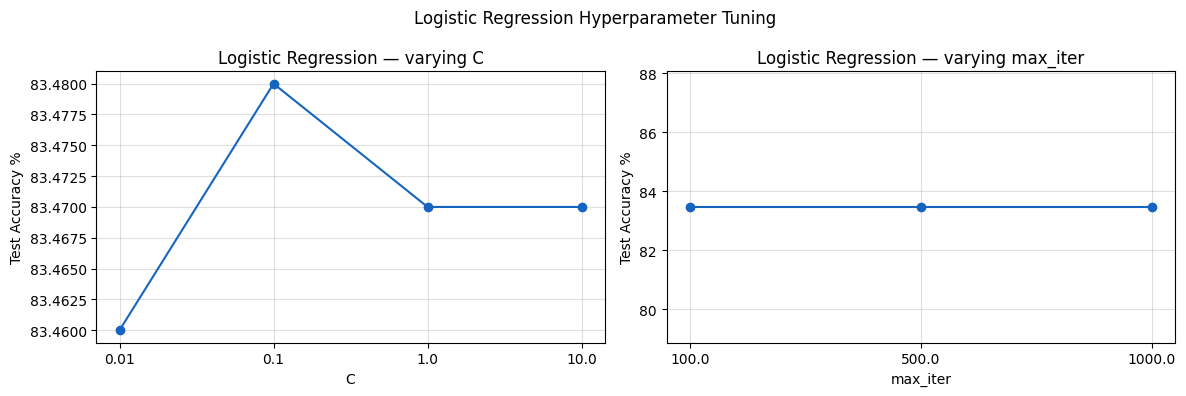

In [17]:
print("="*60)
print("  Logistic Regression — Hyperparameter Tuning")
print("="*60)

lr_tuning = []

# ── Vary C (regularization strength), fix max_iter=1000 ──
print("\n[HP1] Varying C, fixed max_iter=1000")
for C_val in [0.01, 0.1, 1.0, 10.0]:
    mdl = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(solver="lbfgs", max_iter=1000, C=C_val, random_state=42)),
    ])
    mdl.fit(X_tune_linear_sample, y_tune_sample)
    acc = accuracy_score(y_test, mdl.predict(X_test_linear))
    lr_tuning.append({"HP": "C", "Value": C_val, "Accuracy %": round(acc*100, 2)})
    print(f"   C={C_val:<6}  →  Accuracy: {acc*100:.2f}%")

# ── Vary max_iter, fix C=1.0 ──
print("\n[HP2] Varying max_iter, fixed C=1.0")
for iters in [100, 500, 1000]:
    mdl = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(solver="lbfgs", max_iter=iters, C=1.0, random_state=42)),
    ])
    mdl.fit(X_tune_linear_sample, y_tune_sample)
    acc = accuracy_score(y_test, mdl.predict(X_test_linear))
    lr_tuning.append({"HP": "max_iter", "Value": iters, "Accuracy %": round(acc*100, 2)})
    print(f"   max_iter={iters:<5}  →  Accuracy: {acc*100:.2f}%")

lr_tune_df = pd.DataFrame(lr_tuning)
display(lr_tune_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hp in zip(axes, ["C", "max_iter"]):
    sub = lr_tune_df[lr_tune_df["HP"] == hp]
    ax.plot(sub["Value"].astype(str), sub["Accuracy %"], marker="o", color="#1565C0")
    ax.set_title(f"Logistic Regression — varying {hp}")
    ax.set_xlabel(hp); ax.set_ylabel("Test Accuracy %")
    ax.grid(True, alpha=0.4)
plt.suptitle("Logistic Regression Hyperparameter Tuning")
plt.tight_layout()
plt.show()

### 13b. Random Forest — tune `n_estimators` and `max_depth`

  Random Forest — Hyperparameter Tuning

[HP1] Varying n_estimators, fixed max_depth=20
   n_estimators=50    →  Accuracy: 78.29%  (7.4s)
   n_estimators=100   →  Accuracy: 78.41%  (15.9s)
   n_estimators=200   →  Accuracy: 78.48%  (35.8s)
   n_estimators=300   →  Accuracy: 78.51%  (49.8s)

[HP2] Varying max_depth, fixed n_estimators=300
   max_depth=5    →  Accuracy: 74.65%
   max_depth=10   →  Accuracy: 75.24%
   max_depth=20   →  Accuracy: 78.51%


,HP,Value,Accuracy %
0,n_estimators,50,78.29
1,n_estimators,100,78.41
2,n_estimators,200,78.48
3,n_estimators,300,78.51
4,max_depth,5,74.65
5,max_depth,10,75.24
6,max_depth,20,78.51


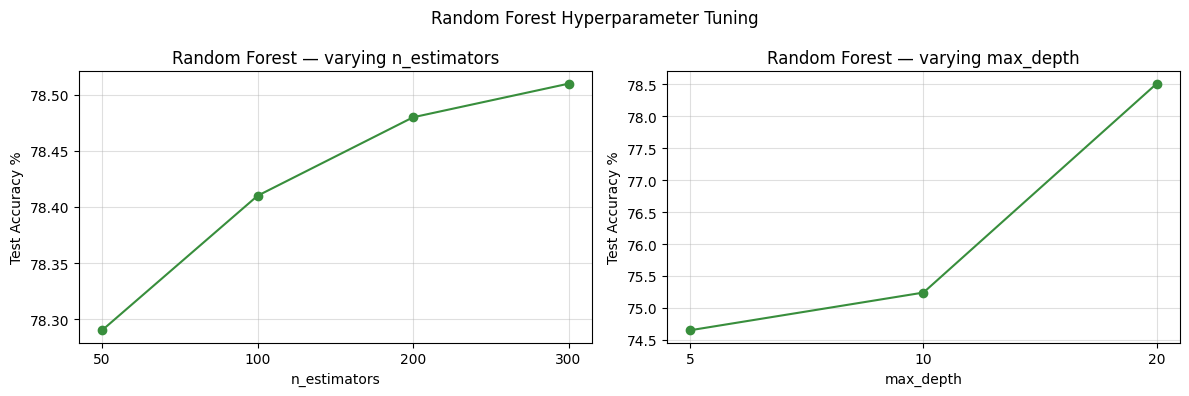

In [18]:
print("="*60)
print("  Random Forest — Hyperparameter Tuning")
print("="*60)

rf_tuning = []

# ── Vary n_estimators, fix max_depth=20 ──
print("\n[HP1] Varying n_estimators, fixed max_depth=20")
for n_est in [50, 100, 200, 300]:
    mdl = RandomForestClassifier(n_estimators=n_est, max_depth=20,
                                  min_samples_leaf=10, max_features="sqrt",
                                  class_weight="balanced", random_state=42, n_jobs=-1)
    t0 = time.time()
    mdl.fit(X_tune_sample, y_tune_sample)
    acc = accuracy_score(y_test, mdl.predict(X_test_tree))
    rf_tuning.append({"HP": "n_estimators", "Value": n_est, "Accuracy %": round(acc*100, 2)})
    print(f"   n_estimators={n_est:<4}  →  Accuracy: {acc*100:.2f}%  ({time.time()-t0:.1f}s)")

# ── Vary max_depth, fix n_estimators=300 ──
print("\n[HP2] Varying max_depth, fixed n_estimators=300")
for depth in [5, 10, 20]:
    mdl = RandomForestClassifier(n_estimators=300, max_depth=depth,
                                  min_samples_leaf=10, max_features="sqrt",
                                  class_weight="balanced", random_state=42, n_jobs=-1)
    mdl.fit(X_tune_sample, y_tune_sample)
    acc = accuracy_score(y_test, mdl.predict(X_test_tree))
    rf_tuning.append({"HP": "max_depth", "Value": depth, "Accuracy %": round(acc*100, 2)})
    print(f"   max_depth={depth:<3}  →  Accuracy: {acc*100:.2f}%")

rf_tune_df = pd.DataFrame(rf_tuning)
display(rf_tune_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hp in zip(axes, ["n_estimators", "max_depth"]):
    sub = rf_tune_df[rf_tune_df["HP"] == hp]
    ax.plot(sub["Value"].astype(str), sub["Accuracy %"], marker="o", color="#388E3C")
    ax.set_title(f"Random Forest — varying {hp}")
    ax.set_xlabel(hp); ax.set_ylabel("Test Accuracy %")
    ax.grid(True, alpha=0.4)
plt.suptitle("Random Forest Hyperparameter Tuning")
plt.tight_layout()
plt.show()

### 13c. XGBoost — tune `learning_rate` and `max_depth`

  XGBoost — Hyperparameter Tuning

[HP1] Varying learning_rate, fixed max_depth=6
   learning_rate=0.01  →  Accuracy: 84.92%
   learning_rate=0.05  →  Accuracy: 85.27%
   learning_rate=0.1  →  Accuracy: 85.24%

[HP2] Varying max_depth, fixed learning_rate=0.05
   max_depth=3  →  Accuracy: 84.96%
   max_depth=6  →  Accuracy: 85.27%
   max_depth=10  →  Accuracy: 85.27%


,HP,Value,Accuracy %
0,learning_rate,0.01,84.92
1,learning_rate,0.05,85.27
2,learning_rate,0.10,85.24
3,max_depth,3.00,84.96
4,max_depth,6.00,85.27
5,max_depth,10.00,85.27


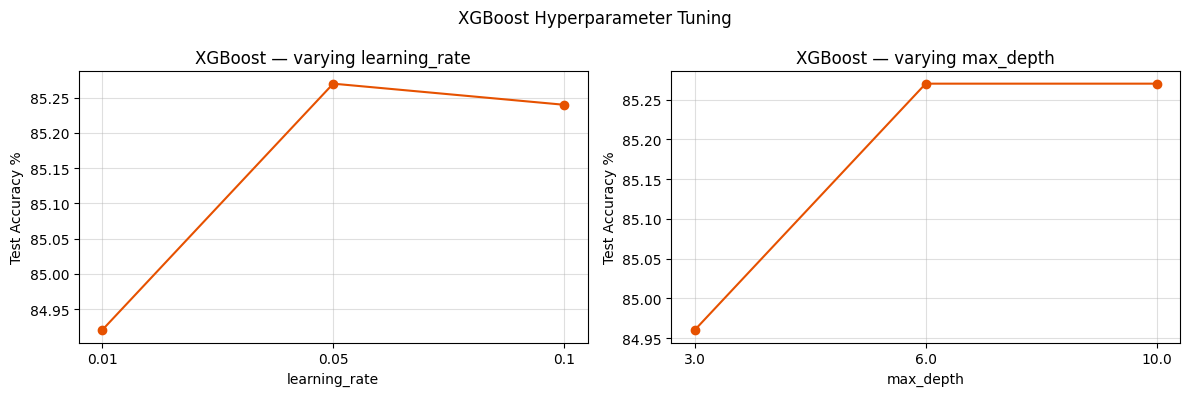

In [19]:
print("="*60)
print("  XGBoost — Hyperparameter Tuning")
print("="*60)

xgb_tuning = []

# ── Vary learning_rate, fix max_depth=6 ──
print("\n[HP1] Varying learning_rate, fixed max_depth=6")
for lr_val in [0.01, 0.05, 0.1]:
    mdl = XGBClassifier(n_estimators=500, learning_rate=lr_val, max_depth=6,
                         subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                         objective="multi:softmax", num_class=4,
                         use_label_encoder=False, eval_metric="mlogloss",
                         random_state=42, n_jobs=-1, verbosity=0)
    mdl.fit(X_tune_sample, y_tune_sample)
    acc = accuracy_score(y_test, mdl.predict(X_test_tree))
    xgb_tuning.append({"HP": "learning_rate", "Value": lr_val, "Accuracy %": round(acc*100, 2)})
    print(f"   learning_rate={lr_val}  →  Accuracy: {acc*100:.2f}%")

# ── Vary max_depth, fix learning_rate=0.05 ──
print("\n[HP2] Varying max_depth, fixed learning_rate=0.05")
for depth in [3, 6, 10]:
    mdl = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=depth,
                         subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                         objective="multi:softmax", num_class=4,
                         use_label_encoder=False, eval_metric="mlogloss",
                         random_state=42, n_jobs=-1, verbosity=0)
    mdl.fit(X_tune_sample, y_tune_sample)
    acc = accuracy_score(y_test, mdl.predict(X_test_tree))
    xgb_tuning.append({"HP": "max_depth", "Value": depth, "Accuracy %": round(acc*100, 2)})
    print(f"   max_depth={depth}  →  Accuracy: {acc*100:.2f}%")

xgb_tune_df = pd.DataFrame(xgb_tuning)
display(xgb_tune_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hp in zip(axes, ["learning_rate", "max_depth"]):
    sub = xgb_tune_df[xgb_tune_df["HP"] == hp]
    ax.plot(sub["Value"].astype(str), sub["Accuracy %"], marker="o", color="#E65100")
    ax.set_title(f"XGBoost — varying {hp}")
    ax.set_xlabel(hp); ax.set_ylabel("Test Accuracy %")
    ax.grid(True, alpha=0.4)
plt.suptitle("XGBoost Hyperparameter Tuning")
plt.tight_layout()
plt.show()

### 13d. Decision Tree — tune `max_depth` and `min_samples_leaf`


  Decision Tree — Hyperparameter Tuning (on 25% sample)

[HP1] Varying max_depth, fixed min_samples_leaf=10
   max_depth=5    →  Accuracy: 68.75%
   max_depth=10   →  Accuracy: 73.10%
   max_depth=20   →  Accuracy: 72.08%

[HP2] Varying min_samples_leaf, fixed max_depth=20
   min_samples_leaf=5    →  Accuracy: 72.39%
   min_samples_leaf=10   →  Accuracy: 72.08%
   min_samples_leaf=50   →  Accuracy: 72.75%


,HP,Value,Accuracy %
0,max_depth,5,68.75
1,max_depth,10,73.10
2,max_depth,20,72.08
3,min_samples_leaf,5,72.39
4,min_samples_leaf,10,72.08
5,min_samples_leaf,50,72.75


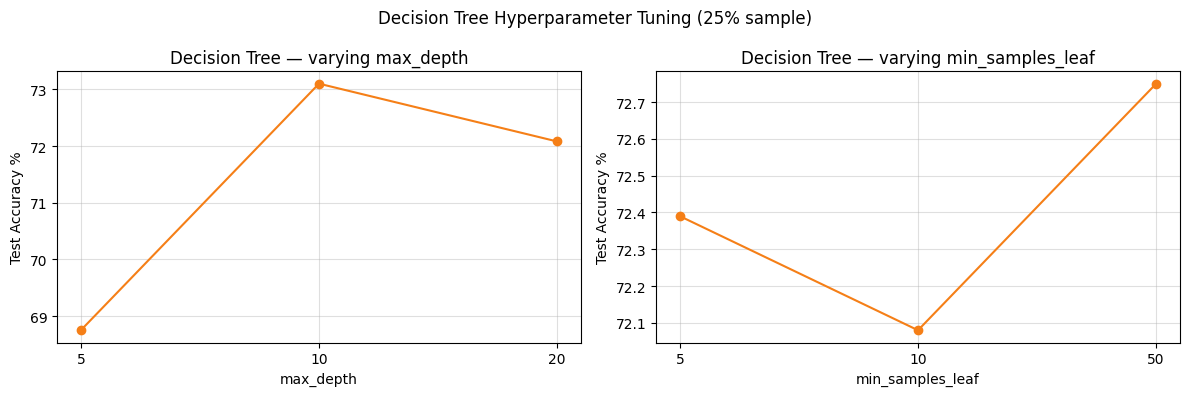

In [20]:
print("="*60)
print("  Decision Tree — Hyperparameter Tuning (on 25% sample)")
print("="*60)

dt_tuning = []

# ── Vary max_depth, fix min_samples_leaf=10 ──
print("\n[HP1] Varying max_depth, fixed min_samples_leaf=10")
for depth in [5, 10, 20]:
    mdl = DecisionTreeClassifier(
        max_depth=depth, min_samples_leaf=10,
        class_weight="balanced", random_state=42,
    )
    mdl.fit(X_tune_sample, y_tune_sample)
    acc = accuracy_score(y_test, mdl.predict(X_test_tree))
    dt_tuning.append({"HP": "max_depth", "Value": depth, "Accuracy %": round(acc*100, 2)})
    print(f"   max_depth={depth:<3}  →  Accuracy: {acc*100:.2f}%")

# ── Vary min_samples_leaf, fix max_depth=20 ──
print("\n[HP2] Varying min_samples_leaf, fixed max_depth=20")
for leaf in [5, 10, 50]:
    mdl = DecisionTreeClassifier(
        max_depth=20, min_samples_leaf=leaf,
        class_weight="balanced", random_state=42,
    )
    mdl.fit(X_tune_sample, y_tune_sample)
    acc = accuracy_score(y_test, mdl.predict(X_test_tree))
    dt_tuning.append({"HP": "min_samples_leaf", "Value": leaf, "Accuracy %": round(acc*100, 2)})
    print(f"   min_samples_leaf={leaf:<3}  →  Accuracy: {acc*100:.2f}%")

dt_tune_df = pd.DataFrame(dt_tuning)
display(dt_tune_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hp in zip(axes, ["max_depth", "min_samples_leaf"]):
    sub = dt_tune_df[dt_tune_df["HP"] == hp]
    ax.plot(sub["Value"].astype(str), sub["Accuracy %"], marker="o", color="#F57F17")
    ax.set_title(f"Decision Tree — varying {hp}")
    ax.set_xlabel(hp); ax.set_ylabel("Test Accuracy %")
    ax.grid(True, alpha=0.4)
plt.suptitle("Decision Tree Hyperparameter Tuning (25% sample)")
plt.tight_layout()
plt.show()


## 14. Final Comparison — 3 Required Bar Charts

  FINAL MODEL COMPARISON


,Model,Accuracy,Train_time,Test_time
0,XGBoost,85.39,208.436,2.3728
1,Logistic Regression,83.47,14.824,0.0819
2,Random Forest,78.25,252.872,4.3085
3,Decision Tree,73.04,34.675,0.1420


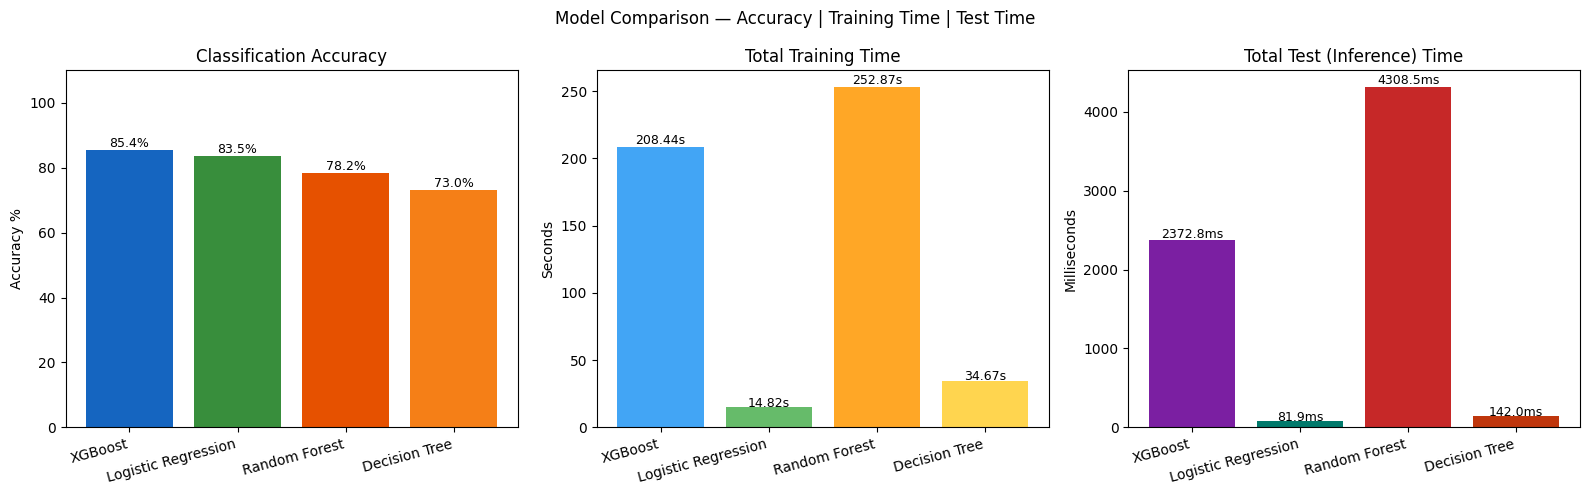


Best model: XGBoost  →  Accuracy: 85.39%


In [21]:
final_df = pd.DataFrame(results).drop_duplicates(subset=["Model"], keep="last")
final_df = final_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("="*60)
print("  FINAL MODEL COMPARISON")
print("="*60)
display(final_df)

x   = np.arange(len(final_df))
labels = final_df["Model"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar 1 — Classification Accuracy
bars = axes[0].bar(x, final_df["Accuracy"], color=["#1565C0", "#388E3C", "#E65100", "#F57F17"][:len(x)])
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=15, ha="right")
axes[0].set_ylabel("Accuracy %")
axes[0].set_title("Classification Accuracy")
axes[0].set_ylim(0, 110)
for bar, val in zip(bars, final_df["Accuracy"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", fontsize=9)

# Bar 2 — Training Time
bars2 = axes[1].bar(x, final_df["Train_time"], color=["#42A5F5", "#66BB6A", "#FFA726", "#FFD54F"][:len(x)])
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=15, ha="right")
axes[1].set_ylabel("Seconds")
axes[1].set_title("Total Training Time")
for bar, val in zip(bars2, final_df["Train_time"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"{val:.2f}s", ha="center", fontsize=9)

# Bar 3 — Test Time
bars3 = axes[2].bar(x, final_df["Test_time"] * 1000, color=["#7B1FA2", "#00796B", "#C62828", "#BF360C"][:len(x)])
axes[2].set_xticks(x); axes[2].set_xticklabels(labels, rotation=15, ha="right")
axes[2].set_ylabel("Milliseconds")
axes[2].set_title("Total Test (Inference) Time")
for bar, val in zip(bars3, final_df["Test_time"] * 1000):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"{val:.1f}ms", ha="center", fontsize=9)

plt.suptitle("Model Comparison — Accuracy | Training Time | Test Time", fontsize=12)
plt.tight_layout()
plt.show()

best = final_df.iloc[0]
print(f"\nBest model: {best['Model']}  →  Accuracy: {best['Accuracy']}%")

## 15. Save Models & Preprocessing Artifacts

Everything needed to reproduce predictions without re-training is saved with `pickle`.

In [22]:
# ── Bundle all preprocessing parameters learned from train ──
preprocessing_bundle = {
    "top_langs":      top_langs,          # top-15 languages from train
    "lang_columns":   lang_tr.columns.tolist(),  # exact dummies from train
    "all_genres":     sorted(all_genres), # genre list from train
    "top_companies":  top_companies,      # top-20 companies from train
    "fill_status":    fill_status,        # median for missing status
    "medians":        medians.to_dict(),  # medians for numeric imputation
    "cap_params":     cap_params,         # (lo, hi) for each capped column
    "keep_mask":      keep_mask,          # VarianceThreshold mask
    "feature_cols":   X_train_tree.columns.tolist(),  # final column order
    "linear_core":    linear_core,        # feature subset for LR
    "level_map":      level_map,          # class label → int
    "level_map_inv":  {v: k for k, v in level_map.items()},  # int → label
    "quality_map":    quality_map,
    "status_map":     status_map,
}

with open("preprocessing.pkl", "wb") as f:
    pickle.dump(preprocessing_bundle, f)

with open("model_lr.pkl",  "wb") as f:
    pickle.dump(best_lr, f)

with open("model_rf.pkl",  "wb") as f:
    pickle.dump(best_rf, f)

with open("model_xgb.pkl", "wb") as f:
    pickle.dump(best_xgb, f)

with open("model_dt.pkl",  "wb") as f:
    pickle.dump(best_dt, f)

print("Saved:")
print("  preprocessing.pkl")
print("  model_lr.pkl")
print("  model_rf.pkl")
print("  model_xgb.pkl")
print("  model_dt.pkl")

Saved:
  preprocessing.pkl
  model_lr.pkl
  model_rf.pkl
  model_xgb.pkl
  model_dt.pkl
